wildlife detection with yolo26 - nano vs small, both fine-tuned from coco weights

I want to see how much the bigger model actually helps and what it costs in speed

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Varun\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
True NVIDIA GeForce RTX 4070 Laptop GPU


## model 1 - yolo26n (nano)

In [4]:
# if training hangs on windows, set workers=0
model_n = YOLO("yolo26n.pt")

model_n.train(
    data="african-wildlife.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    name="wildlife_n",
)

Ultralytics 8.4.174  Python-3.10.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wildlife_n, nbs=64, nms=None, opset=None, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C811058C70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [5]:
save_dir_n = Path(model_n.trainer.save_dir)
print(save_dir_n)
print(list(save_dir_n.glob("*"))[:10])

C:\Users\Varun\Jupiter Notebooks\runs\detect\wildlife_n
[WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/args.yaml'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/BoxF1_curve.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/BoxPR_curve.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/BoxP_curve.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/BoxR_curve.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/confusion_matrix.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/confusion_matrix_normalized.png'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/labels.jpg'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/results.csv'), WindowsPath('C:/Users/Varun/Jupiter Notebooks/runs/detect/wildlife_n/results.png')]


## model 2 - yolo26s (small)

In [9]:
model_s = YOLO("yolo26s.pt")

model_s.train(
    data="african-wildlife.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    name="wildlife_s",
)

Ultralytics 8.4.174  Python-3.10.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wildlife_s, nbs=64, nms=None, opset=None, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C968BC6050>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [11]:
save_dir_s = Path(model_s.trainer.save_dir)
print(save_dir_s)

C:\Users\Varun\Jupiter Notebooks\runs\detect\wildlife_s


## evaluate both on the val set

In [14]:
# load the best weights from each run
best_n = YOLO(save_dir_n / "weights" / "best.pt")
best_s = YOLO(save_dir_s / "weights" / "best.pt")

m_n = best_n.val(data="african-wildlife.yaml")
m_s = best_s.val(data="african-wildlife.yaml")

Ultralytics 8.4.174  Python-3.10.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 503.8409.5 MB/s, size: 99.8 KB)
val: Scanning C:\Games\lada\datasets\african-wildlife\labels\val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.1it/s 14.1s0.1s
                   all        225        379      0.921      0.924      0.958       0.82
               buffalo         62         89      0.961      0.888       0.96      0.834
              elephant         53         91      0.857      0.934      0.953      0.817
                 rhino         55         85      0.953      0.961      0.969       0.87
                 zebra         59        114      0.914      0.912      0.951       0.76
Speed: 1.

In [18]:
def summarize(name, model):
    return {
        "model": name,
        "precision": round(float(model.box.mp), 3),
        "recall": round(float(model.box.mr), 3),
        "mAP50": round(float(model.box.map50), 3),
        "mAP50-95": round(float(model.box.map), 3),
        "inference_ms": round(model.speed["inference"], 2),
    }

comparison = pd.DataFrame([summarize("yolo26n", m_n), summarize("yolo26s", m_s)])
comparison

,model,precision,recall,mAP50,mAP50-95,inference_ms
0,yolo26n,0.921,0.924,0.958,0.820,3.57
1,yolo26s,0.935,0.912,0.964,0.825,6.36


In [20]:
# per class map50-95, want to see if some animals are harder than others
names = best_s.names
per_class = pd.DataFrame({
    "class": [names[i] for i in m_s.box.ap_class_index],
    "yolo26n": m_n.box.maps[m_n.box.ap_class_index].round(3),
    "yolo26s": m_s.box.maps[m_s.box.ap_class_index].round(3),
})
per_class

,class,yolo26n,yolo26s
0,buffalo,0.834,0.831
1,elephant,0.817,0.812
2,rhino,0.870,0.862
3,zebra,0.760,0.794


## look at the training curves and confusion matrix

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

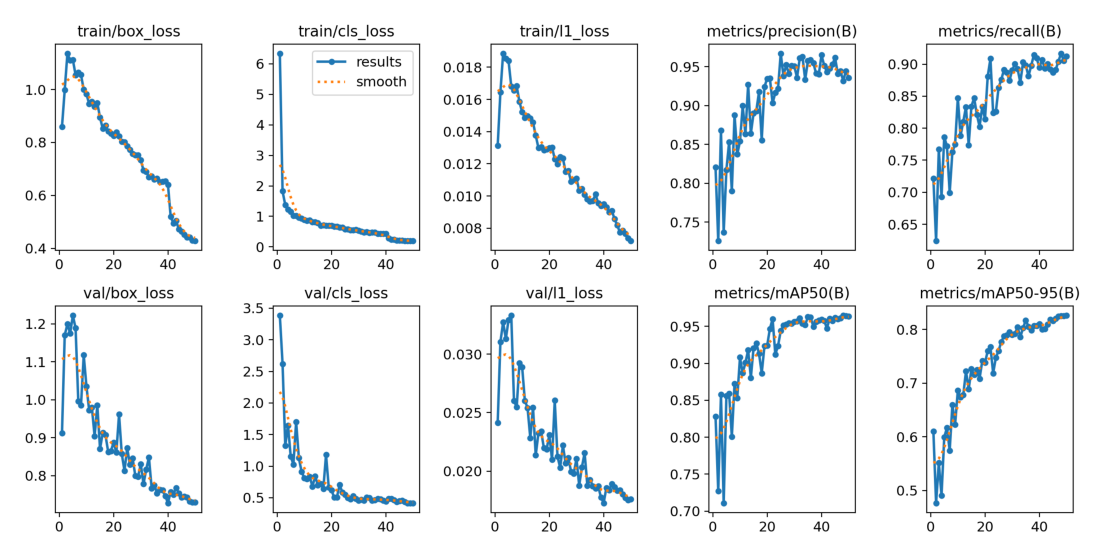

In [22]:
img = plt.imread(save_dir_s / "results.png")
plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

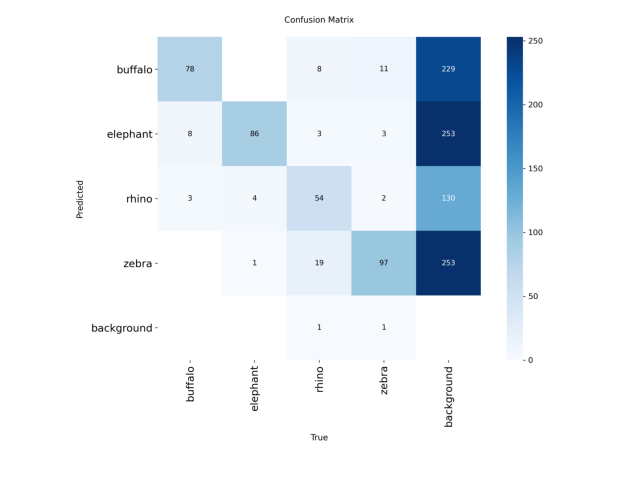

In [24]:
img = plt.imread(save_dir_s / "confusion_matrix.png")
plt.figure(figsize=(8, 7))
plt.imshow(img)
plt.axis("off")

## try it on some images

the val images are fine but its more convincing to also try a few pics from the internet / your own, put them in a folder called test_images


image 1/1 C:\Users\Varun\Jupiter Notebooks\african-wildlife-sample.jpg: 416x640 1 elephant, 26.7ms
Speed: 3.1ms preprocess, 26.7ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)


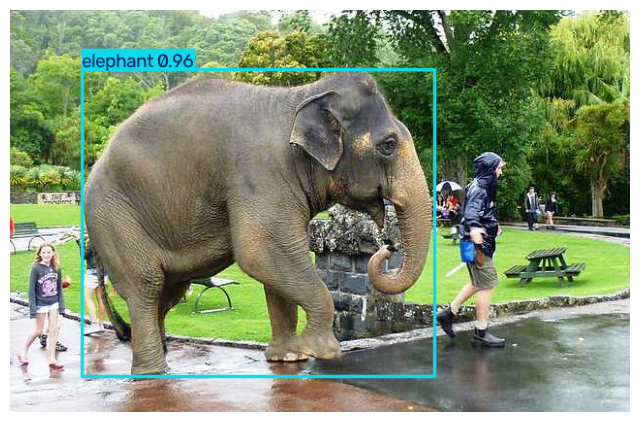

In [26]:
preds = best_s.predict("https://ultralytics.com/assets/african-wildlife-sample.jpg", conf=0.25)
plt.figure(figsize=(8, 6))
plt.imshow(preds[0].plot()[..., ::-1])  # bgr -> rgb
plt.axis("off")
plt.savefig("sample_prediction.png", bbox_inches="tight")

In [28]:
# own images, skip this cell if you dont have thenm
test_dir = Path("test_images")
if test_dir.exists():
    for p in list(test_dir.glob("*"))[:4]:
        r = best_s.predict(str(p), conf=0.25)[0]
        plt.figure(figsize=(7, 5))
        plt.imshow(r.plot()[..., ::-1])
        plt.title(p.name)
        plt.axis("off")

## confidence threshold

same model, different conf cutoff - interesting to see how detections change

In [31]:
sample = "https://ultralytics.com/assets/african-wildlife-sample.jpg"
for c in [0.1, 0.25, 0.5, 0.75]:
    r = best_s.predict(sample, conf=c, verbose=False)[0]
    print(f"conf>={c}: {len(r.boxes)} detections")

Found https://ultralytics.com/assets/african-wildlife-sample.jpg locally at african-wildlife-sample.jpg
conf>=0.1: 1 detections
Found https://ultralytics.com/assets/african-wildlife-sample.jpg locally at african-wildlife-sample.jpg
conf>=0.25: 1 detections
Found https://ultralytics.com/assets/african-wildlife-sample.jpg locally at african-wildlife-sample.jpg
conf>=0.5: 1 detections
Found https://ultralytics.com/assets/african-wildlife-sample.jpg locally at african-wildlife-sample.jpg
conf>=0.75: 1 detections


In [33]:
import shutil

# nano is good enough so we'll skip the small one
shutil.copy(save_dir_n / "weights" / "best.pt", "wildlife_best.pt")
print("copied")

copied
